# 03 — Baseline Results Analysis

This notebook evaluates the **baseline SEC risk classifier** built using:

- **TF-IDF features**
- **Logistic Regression**

The purpose of this notebook is to:

- assess baseline performance
- understand class-level strengths and weaknesses
- inspect misclassifications
- identify why a transformer-based model (FinBERT) is needed

In [ ]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

In [ ]:
df = pd.read_csv("../data/annotation_sample.csv")
df = df[df["manual_label"].notna()].copy()
df["manual_label"] = df["manual_label"].astype(str).str.strip()

print("Total labeled rows:", len(df))
df.head()

Total labeled rows: 200


,id,text,weak_label,manual_label
0,167,the company’s business requires it to use and ...,neutral,neutral
1,249,we make significant investments in products an...,positive_outlook,negative_risk
2,85,the company is also currently subject to antit...,negative_risk,negative_risk
3,169,the company experiences malicious attacks and ...,negative_risk,negative_risk
4,188,"the technology industry, including, in some in...",negative_risk,negative_risk


## Initial Dataset Check

The baseline model is evaluated on the manually annotated subset of the corpus rather than the full predicted corpus. This is important because it provides a **human-validated benchmark** for model quality.

The output confirms that the evaluation dataset contains **200 labeled paragraphs**, which is enough to establish a baseline but still small enough that minority-class performance should be interpreted carefully.


The baseline model was trained and evaluated on the **manually labeled subset** of the corpus.

This evaluation set contains 200 annotated SEC paragraphs labeled as:

- `negative_risk`
- `neutral`
- `positive_outlook`

In [ ]:
df["manual_label"].value_counts()

manual_label
negative_risk       161
neutral              29
positive_outlook     10
Name: count, dtype: int64

In [ ]:
(df["manual_label"].value_counts(normalize=True) * 100).round(2)

manual_label
negative_risk       80.5
neutral             14.5
positive_outlook     5.0
Name: proportion, dtype: float64

## Class Imbalance and Why It Matters

The label distribution is highly imbalanced:

- **negative_risk:** 161 paragraphs (**80.5%**)
- **neutral:** 29 paragraphs (**14.5%**)
- **positive_outlook:** 10 paragraphs (**5.0%**)

This imbalance is expected because the source material comes from SEC risk disclosures, where downside scenarios dominate. It also means that **accuracy alone is not enough** to judge model quality. A model can score well by over-predicting the majority class, so macro-level metrics and confusion patterns are more informative.


The manually labeled dataset is **highly imbalanced**, with the majority of paragraphs belonging to the `negative_risk` class.

This imbalance is expected because the source text primarily comes from SEC risk disclosures, which emphasize downside scenarios and uncertainty.

In [ ]:
label_map = {
    "negative_risk": 0,
    "neutral": 1,
    "positive_outlook": 2,
}

inverse_label_map = {v: k for k, v in label_map.items()}

df["label"] = df["manual_label"].map(label_map)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## Experimental Setup

The notebook recreates the same stratified train/test split used in the training script:

- **80% training set**
- **20% test set**
- `random_state=42`
- stratification by label

Using the same split ensures that the notebook is analyzing the exact same benchmark configuration that was saved in `training/train_baseline.py`.


In [ ]:
with open("../models/risk_baseline.pkl", "rb") as f:
    artifact = pickle.load(f)

model = artifact["model"]
vectorizer = artifact["vectorizer"]

print(model)

LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)


In [ ]:
X_test_vec = vectorizer.transform(X_test)

preds = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, preds)
print("Accuracy:", round(accuracy,4))

Accuracy: 0.825


## Baseline Accuracy

The saved baseline model achieves **0.825 accuracy** on the held-out test set.

This is a useful starting point, but it should be interpreted alongside the class distribution. Because the dataset is dominated by `negative_risk`, raw accuracy is somewhat flattering. The more important question is whether the model can distinguish **neutral** and especially **positive_outlook** from negative risk language.


In [ ]:
print(
    classification_report(
        y_test,
        preds,
        target_names=["negative_risk","neutral","positive_outlook"],
        zero_division=0
    )
)

                  precision    recall  f1-score   support

   negative_risk       0.93      0.88      0.90        32
         neutral       0.56      0.83      0.67         6
positive_outlook       0.00      0.00      0.00         2

        accuracy                           0.82        40
       macro avg       0.50      0.57      0.52        40
    weighted avg       0.83      0.82      0.82        40



## Classification Report Interpretation

The baseline performs best on the dominant class:

- **negative_risk:** precision 0.93, recall 0.88, F1 0.90
- **neutral:** precision 0.56, recall 0.83, F1 0.67
- **positive_outlook:** precision 0.00, recall 0.00, F1 0.00

Two conclusions matter most:

1. The baseline is already **strong at identifying clear negative-risk language**.
2. It **fails completely on the smallest class (`positive_outlook`)**.

This is exactly the kind of limitation that motivates moving from bag-of-words methods to contextual transformer models such as FinBERT.


While the baseline achieves strong overall accuracy, accuracy alone is misleading because the dataset is highly imbalanced.

The macro-average F1 score provides a more balanced evaluation across classes.

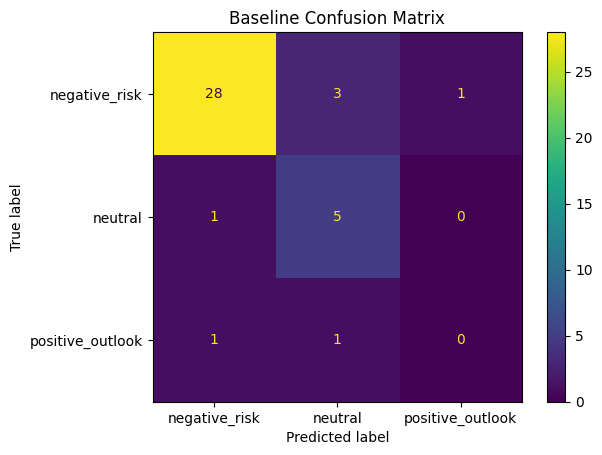

In [ ]:
cm = confusion_matrix(y_test, preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["negative_risk","neutral","positive_outlook"]
)

disp.plot()
plt.title("Baseline Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows that the baseline model is reliable on `negative_risk` and reasonably good on `neutral`, but it struggles with the subtle language used in `positive_outlook` paragraphs.

This is consistent with how TF-IDF works: it is good at recognizing **obvious lexical cues** such as *adverse*, *significant*, or *risk*, but much weaker when the distinction depends on broader semantic framing.


In [ ]:
pd.Series(preds).map(inverse_label_map).value_counts()

negative_risk       30
neutral              9
positive_outlook     1
Name: count, dtype: int64

## Prediction Bias

The baseline predicts:

- **30** `negative_risk`
- **9** `neutral`
- **1** `positive_outlook`

Even though the test set contains 2 positive outlook examples, the model only predicts that class once. This confirms a **systematic bias toward the majority class** and suggests the baseline is conservative when encountering future-oriented or strategic language.


The baseline model shows a bias toward predicting **negative risk statements**, reflecting the dominant class in the training data.

In [ ]:
results_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": [inverse_label_map[i] for i in y_test],
    "pred_label": [inverse_label_map[i] for i in preds],
})

results_df.head()

,text,true_label,pred_label
0,the company’s products and services are design...,negative_risk,negative_risk
1,we derive substantial revenue from licenses of...,negative_risk,negative_risk
2,if our goodwill or amortizable intangible asse...,negative_risk,negative_risk
3,the company has international operations with ...,positive_outlook,neutral
4,while the company maintains insurance coverage...,negative_risk,negative_risk


In [ ]:
mistakes_df = results_df[results_df["true_label"] != results_df["pred_label"]]

print("Total mistakes:", len(mistakes_df))
mistakes_df.head(10)

Total mistakes: 7


,text,true_label,pred_label
3,the company has international operations with ...,positive_outlook,neutral
7,the company distributes its products and certa...,neutral,negative_risk
12,the company’s operations and performance depen...,negative_risk,neutral
13,the company’s business is subject to a variety...,negative_risk,neutral
15,the company distributes third-party applicatio...,negative_risk,neutral
16,continuing to enhance the attractiveness of ou...,positive_outlook,negative_risk
30,our increasing focus on cloud-based services p...,negative_risk,positive_outlook


## Misclassification Review

The notebook reports **7 total mistakes** in the held-out test set. This is not a large number, but the distribution of those errors is informative.

The baseline most commonly confuses:

- `negative_risk` → `neutral`
- `positive_outlook` → `negative_risk`
- `positive_outlook` → `neutral`

These errors reveal the baseline's weakness: it relies on isolated words rather than the **overall intent of the paragraph**.


In [ ]:
mistakes_df.groupby(["true_label","pred_label"]).size().sort_values(ascending=False)

true_label        pred_label      
negative_risk     neutral             3
                  positive_outlook    1
neutral           negative_risk       1
positive_outlook  negative_risk       1
                  neutral             1
dtype: int64

## Error Type Summary

The most common error type is `negative_risk` being predicted as `neutral` (3 cases), followed by single instances of:

- `negative_risk` → `positive_outlook`
- `neutral` → `negative_risk`
- `positive_outlook` → `negative_risk`
- `positive_outlook` → `neutral`

This pattern shows that the model has far more trouble with the **minority classes** than with the dominant risk class.


The most common errors involve confusing **neutral statements with risk statements**, and misclassifying **positive outlook paragraphs** due to lexical overlap with risk terminology.

In [ ]:
mistakes_df[mistakes_df["true_label"] == "positive_outlook"]

,text,true_label,pred_label
3,the company has international operations with ...,positive_outlook,neutral
16,continuing to enhance the attractiveness of ou...,positive_outlook,negative_risk


## Positive Outlook Errors

Both misclassified `positive_outlook` examples are useful because they highlight the baseline's central limitation.

One example is an international-operations statement that the model predicted as `neutral`. Another is a cloud-platform growth statement that the model predicted as `negative_risk`.

These mistakes make sense for TF-IDF: the model sees words like *cloud*, *platform*, *market*, and *operations*, which also appear frequently in risk disclosures, but it cannot reliably infer the **strategic / growth-oriented framing** of the full sentence.


In [ ]:
mistakes_df[mistakes_df["true_label"] == "neutral"]

,text,true_label,pred_label
7,the company distributes its products and certa...,neutral,negative_risk


## Neutral Errors

The neutral-class mistakes are also intuitive. The model tends to over-read **dependency language** as risk language because phrases like *depends on*, *distributes through*, or *operations depend on* often occur in risk-heavy SEC text.

This shows that the baseline is sensitive to formal business language, but not always good at separating **descriptive setup** from **actual negative risk disclosure**.


In [ ]:
feature_names = vectorizer.get_feature_names_out()

class_names = ["negative_risk","neutral","positive_outlook"]

for i, class_name in enumerate(class_names):
    
    top_ids = np.argsort(model.coef_[i])[-15:]
    
    print("\nTop words for", class_name)
    print([feature_names[j] for j in top_ids])


Top words for negative_risk
['information', 'affect', 'foreign', 'impact', 'certain', 'value', 'margins', 'business', 'tax', 'adversely', 'content', 'significant', 'company', 'new', 'products']

Top words for neutral
['fluctuate', 'item', 'net', 'software', 'store', 'remain', 'quarterly', 'performance', 'expects', 'data', 'company', 'outside', 'future', 'results', 'depends']

Top words for positive_outlook
['functions', 'productivity', 'engineering', 'practices', 'policies', 'effectively', 'effectiveness', 'sustain', 'adequate', 'based', 'capacity', 'datacenter', 'operations', 'devices', 'cloud']


## What the Feature Weights Show

The top-weighted words for each class reveal exactly how the baseline works.

For `negative_risk`, the model emphasizes words such as:

- *margins*
- *adversely*
- *significant*
- *tax*
- *business*

For `neutral`, it emphasizes terms such as:

- *depends*
- *results*
- *future*
- *outside*
- *quarterly*

For `positive_outlook`, it emphasizes words like:

- *effectively*
- *engineering*
- *productivity*
- *functions*

These weights are interpretable and helpful, but they also show the core limitation of TF-IDF: the model is driven by **token-level associations**, not true contextual understanding.


The baseline classifier relies heavily on **keyword-level signals**, which explains why it performs well for obvious risk language but struggles with more nuanced statements.

# Baseline Model Findings

The TF-IDF + Logistic Regression baseline provides a useful benchmark for SEC paragraph classification.

Key observations:

• Strong performance on the dominant negative risk class  
• Moderate performance on neutral statements  
• Weak performance on positive outlook paragraphs  

These limitations stem from the fact that TF-IDF captures **surface vocabulary patterns rather than semantic context**.

This motivates the transition to a **transformer-based model (FinBERT)**, which can capture contextual meaning in financial language.

## Overall Interpretation

The baseline model serves its intended purpose well:

- it establishes a transparent and interpretable benchmark,
- it performs strongly on the dominant `negative_risk` class,
- and it exposes the main challenge of the task: **minority-class semantic nuance**.

The most important takeaway is not simply that accuracy is 0.825. It is that the baseline cannot reliably recognize `positive_outlook`, even when it performs well on the majority class. This provides a strong motivation for the next stage of the project: **using FinBERT to capture contextual financial language more effectively**.
